# Import Libraries

In [2]:
import math
import pylidc as pl
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import clear_border
from skimage import measure
from skimage.measure import label, regionprops
from scipy import ndimage as ndi
from scipy.ndimage import measurements, center_of_mass, binary_dilation, zoom
from skimage.morphology import binary_closing, binary_opening, disk

In [3]:
# Visualization Function
def show_slices_grid(volume, cols=6, figsize_scale=2, cmap="viridis", titles=True, interpolation=None):
    num_slices = volume.shape[0]
    rows = math.ceil(num_slices / cols)

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(cols * figsize_scale, rows * figsize_scale)
    )

    if rows == 1 and cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i in range(num_slices):
        axes[i].imshow(
            volume[i],
            interpolation=interpolation,
            cmap=cmap,
        )

        if titles:
            axes[i].set_title(f'{i}', fontsize=8)

        axes[i].axis('off')

    for j in range(num_slices, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
    
# Visualization Function
def show_labeled_slices_grid(masks, cols=6, figsize_scale=2, cmap='nipy_spectral', connectivity=None):
    num_slices = masks.shape[0]
    rows = math.ceil(num_slices / cols)

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(cols * figsize_scale,
                 rows * figsize_scale)
    )

    axes = axes.flatten()

    for i in range(num_slices):

        labels = label(
            masks[i],
            connectivity=connectivity
        )

        axes[i].imshow(labels, cmap=cmap)

        axes[i].set_title(
            f'Slice {i}',
            fontsize=8
        )

        axes[i].axis('off')

    for j in range(num_slices, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Convert DICOM Files Into HU Units NumPy Array

In [4]:
# LIDC-IDRI-0078 Data Query
patient_id = 'LIDC-IDRI-0078'
scan = pl.query(pl.Scan).filter(pl.Scan.patient_id == patient_id).first()

# Load All LIDC-IDRI-0078 DICOM Files
images = scan.load_all_dicom_images()

# Get Pixel Array of All Slices
volumes = np.stack([img.pixel_array for img in images]).astype(np.int16)

# Get Slope and Intecept Information
slope = float(images[0].RescaleSlope)
intercept = float(images[0].RescaleIntercept)

# HU Units Conversion
hu_volumes = volumes * slope + intercept
hu_volumes = hu_volumes.astype(np.int16)

print(hu_volumes.shape)

Loading dicom files ... This may take a moment.
(87, 512, 512)


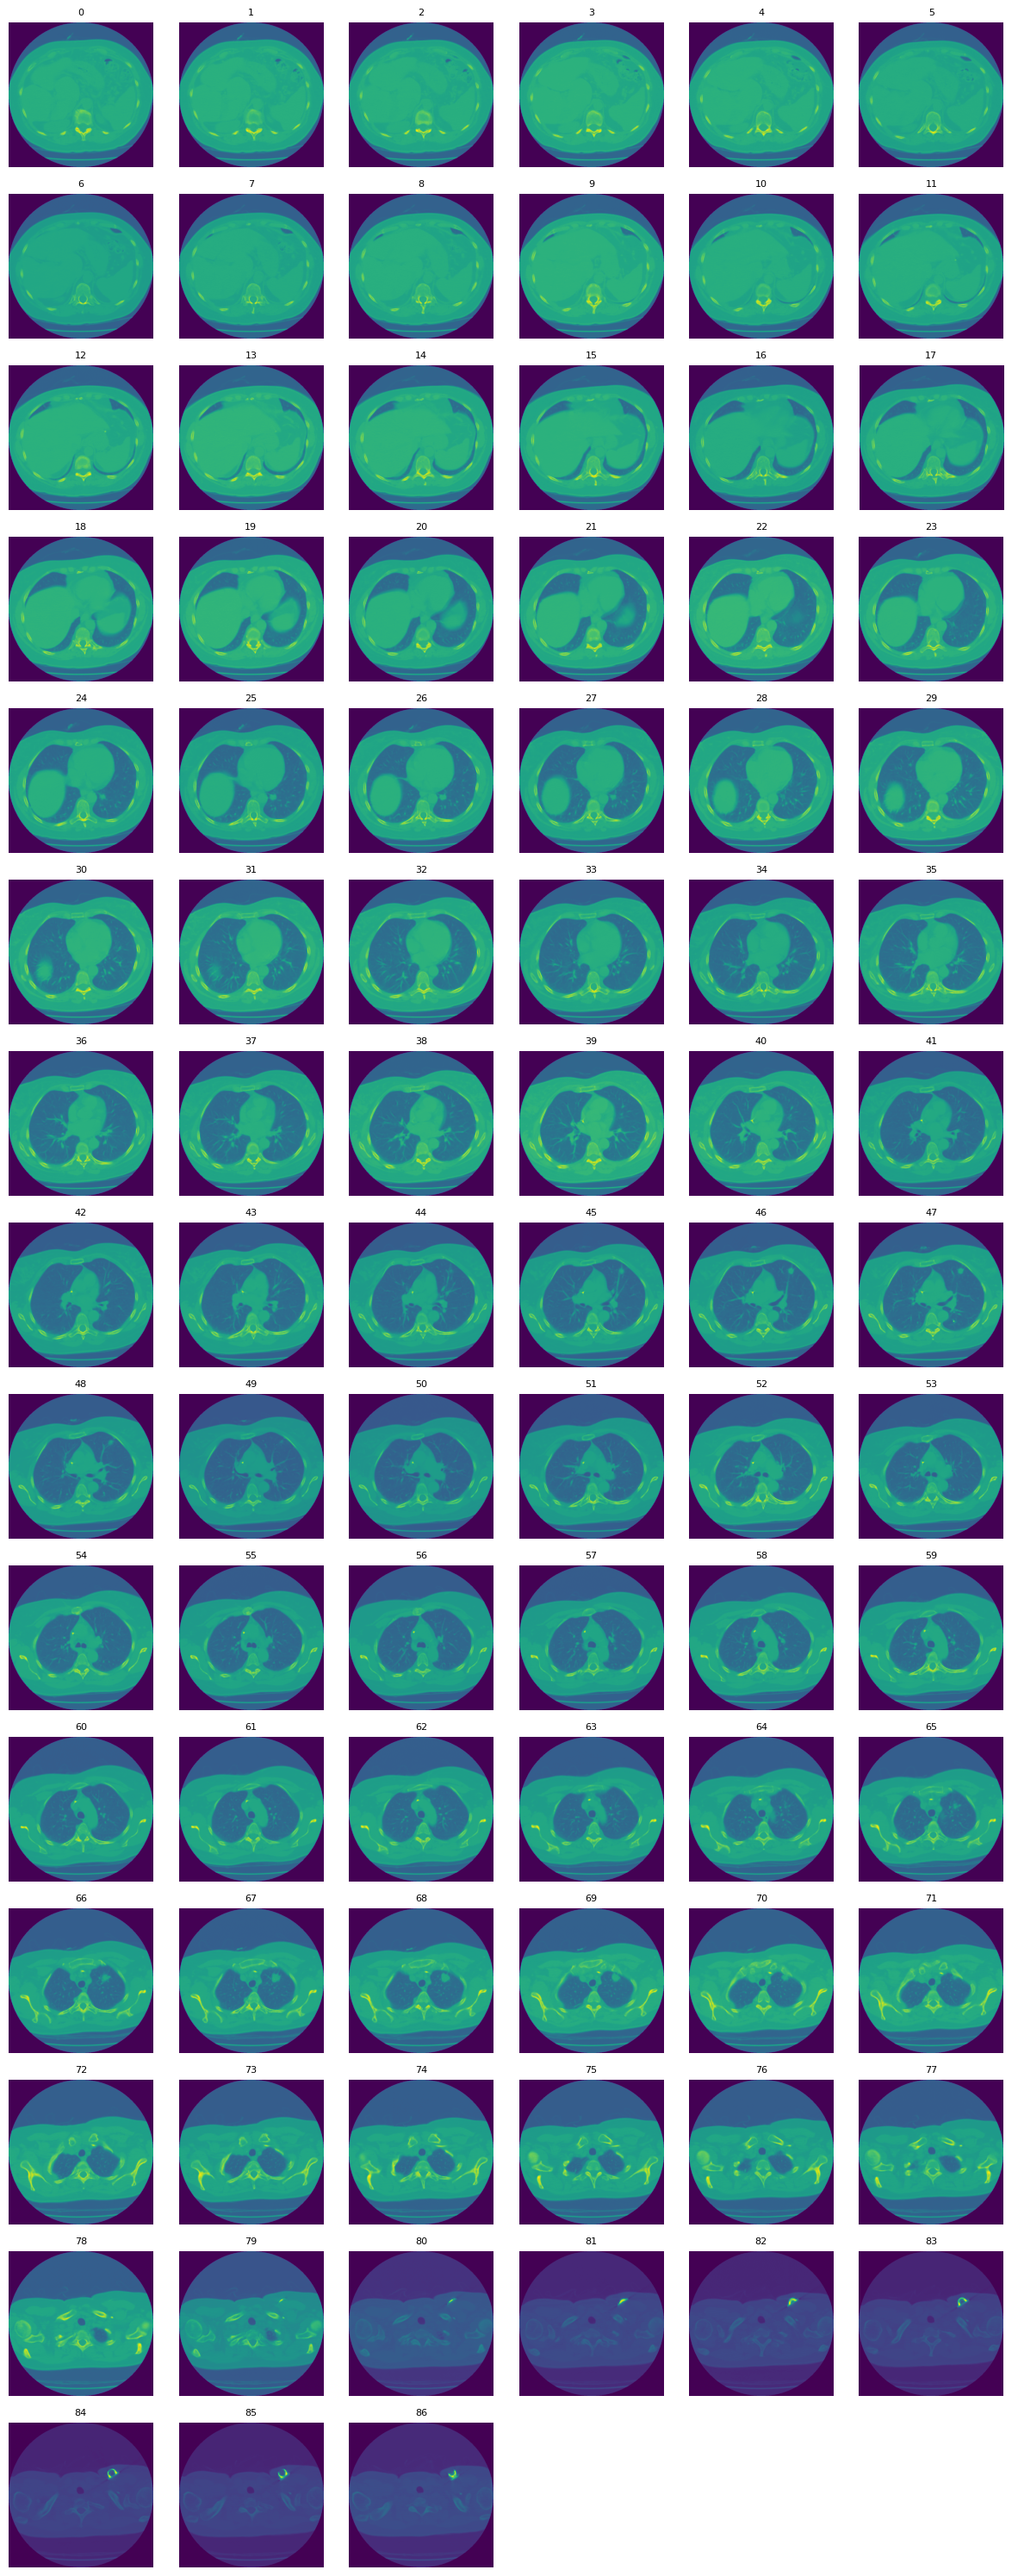

In [5]:
# Visualization
show_slices_grid(hu_volumes)

# Threshold Mask

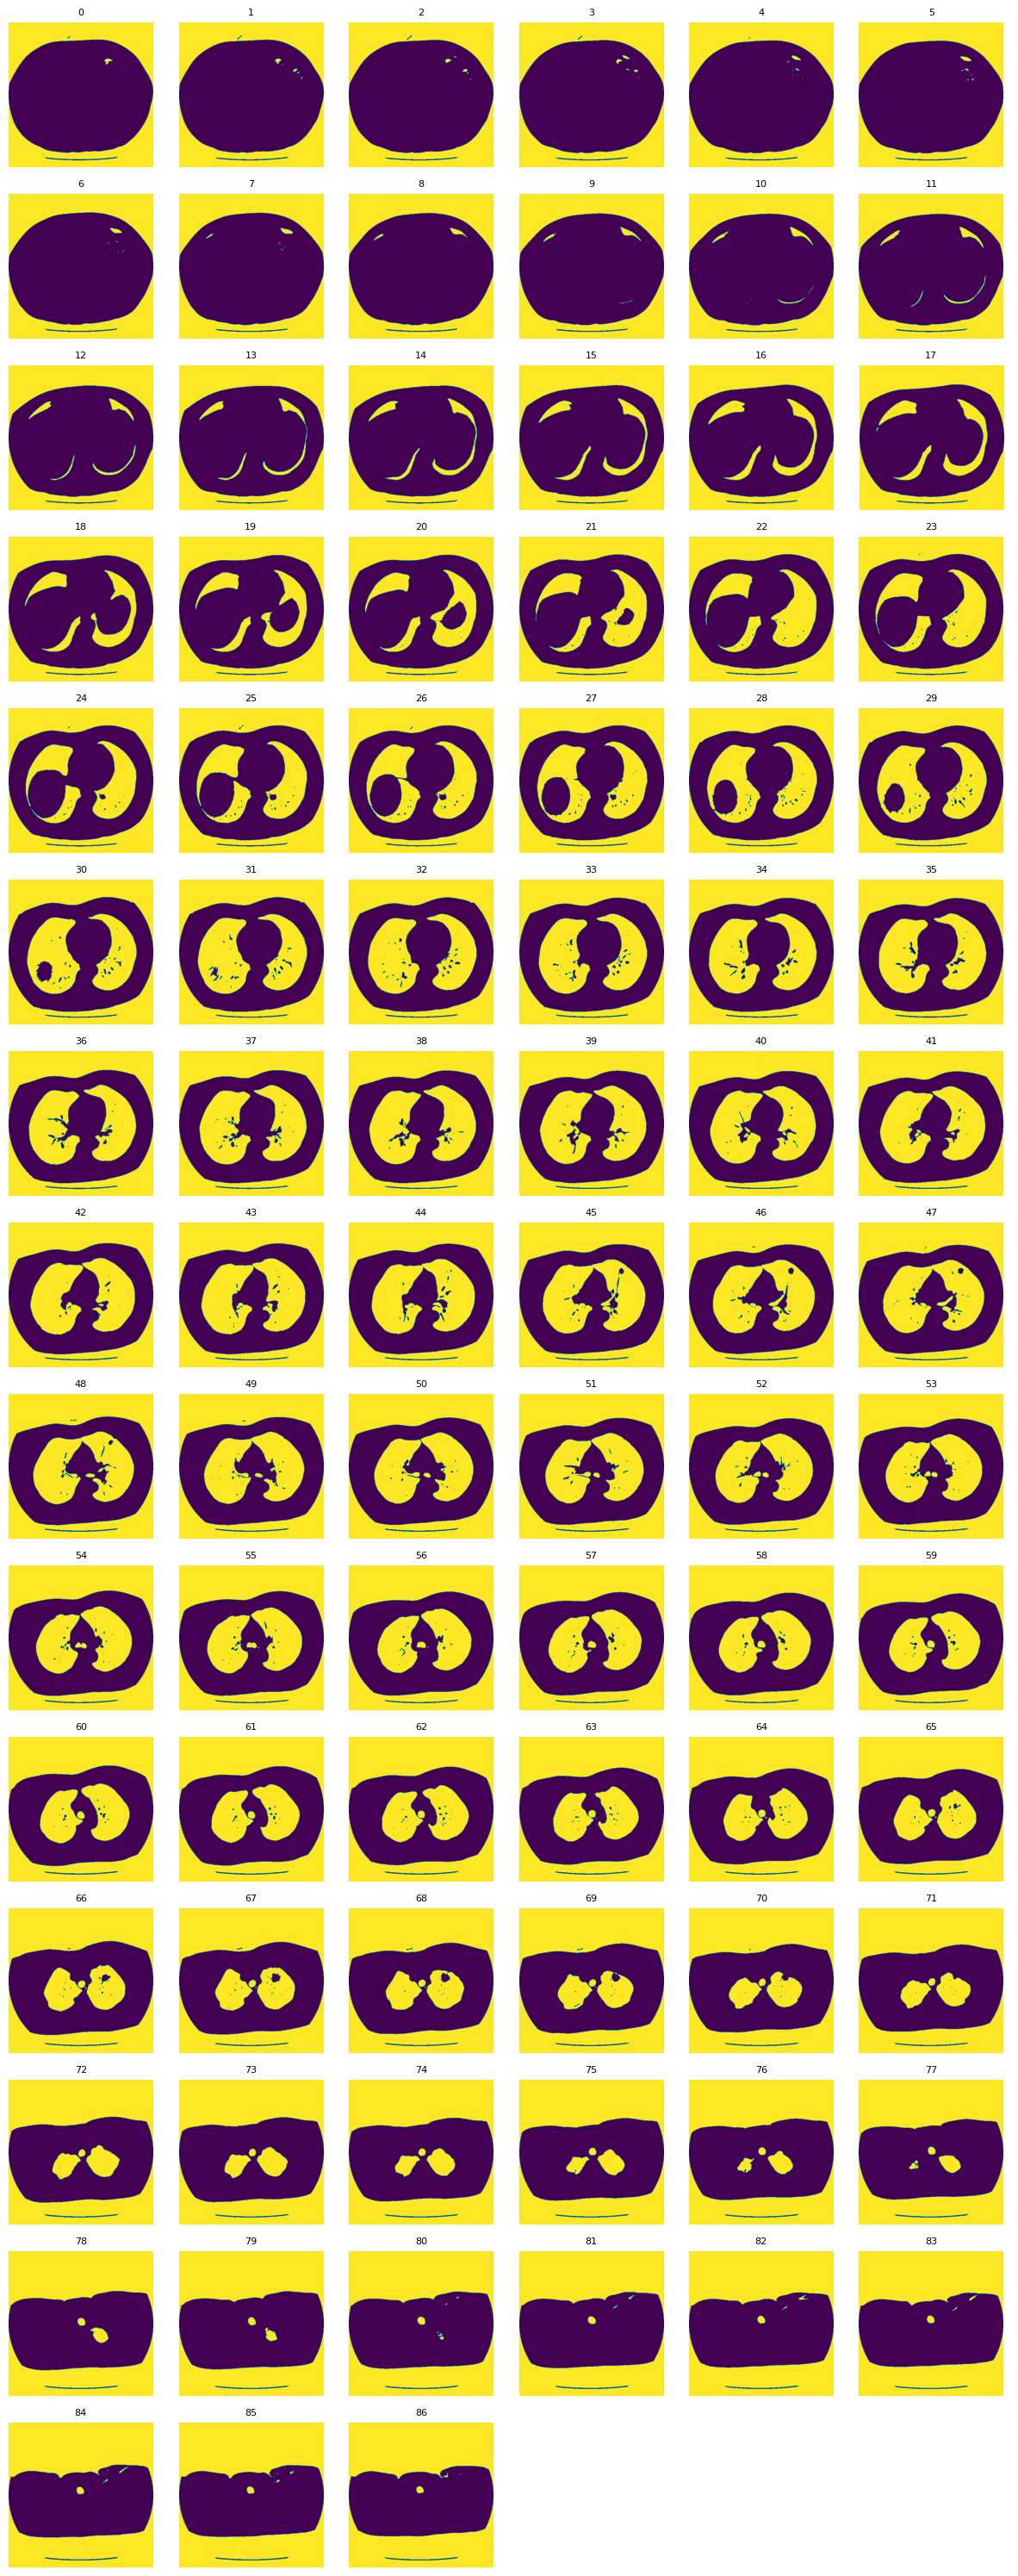

In [6]:
# Threshold Mask
masks = hu_volumes < -320

# Visualization
show_slices_grid(masks)

# Remove The Outer Border

np.vectorize(): 
- https://numpy.org/doc/stable/reference/generated/numpy.vectorize.html
- https://www.geeksforgeeks.org/numpy/vectorized-operations-in-numpy/

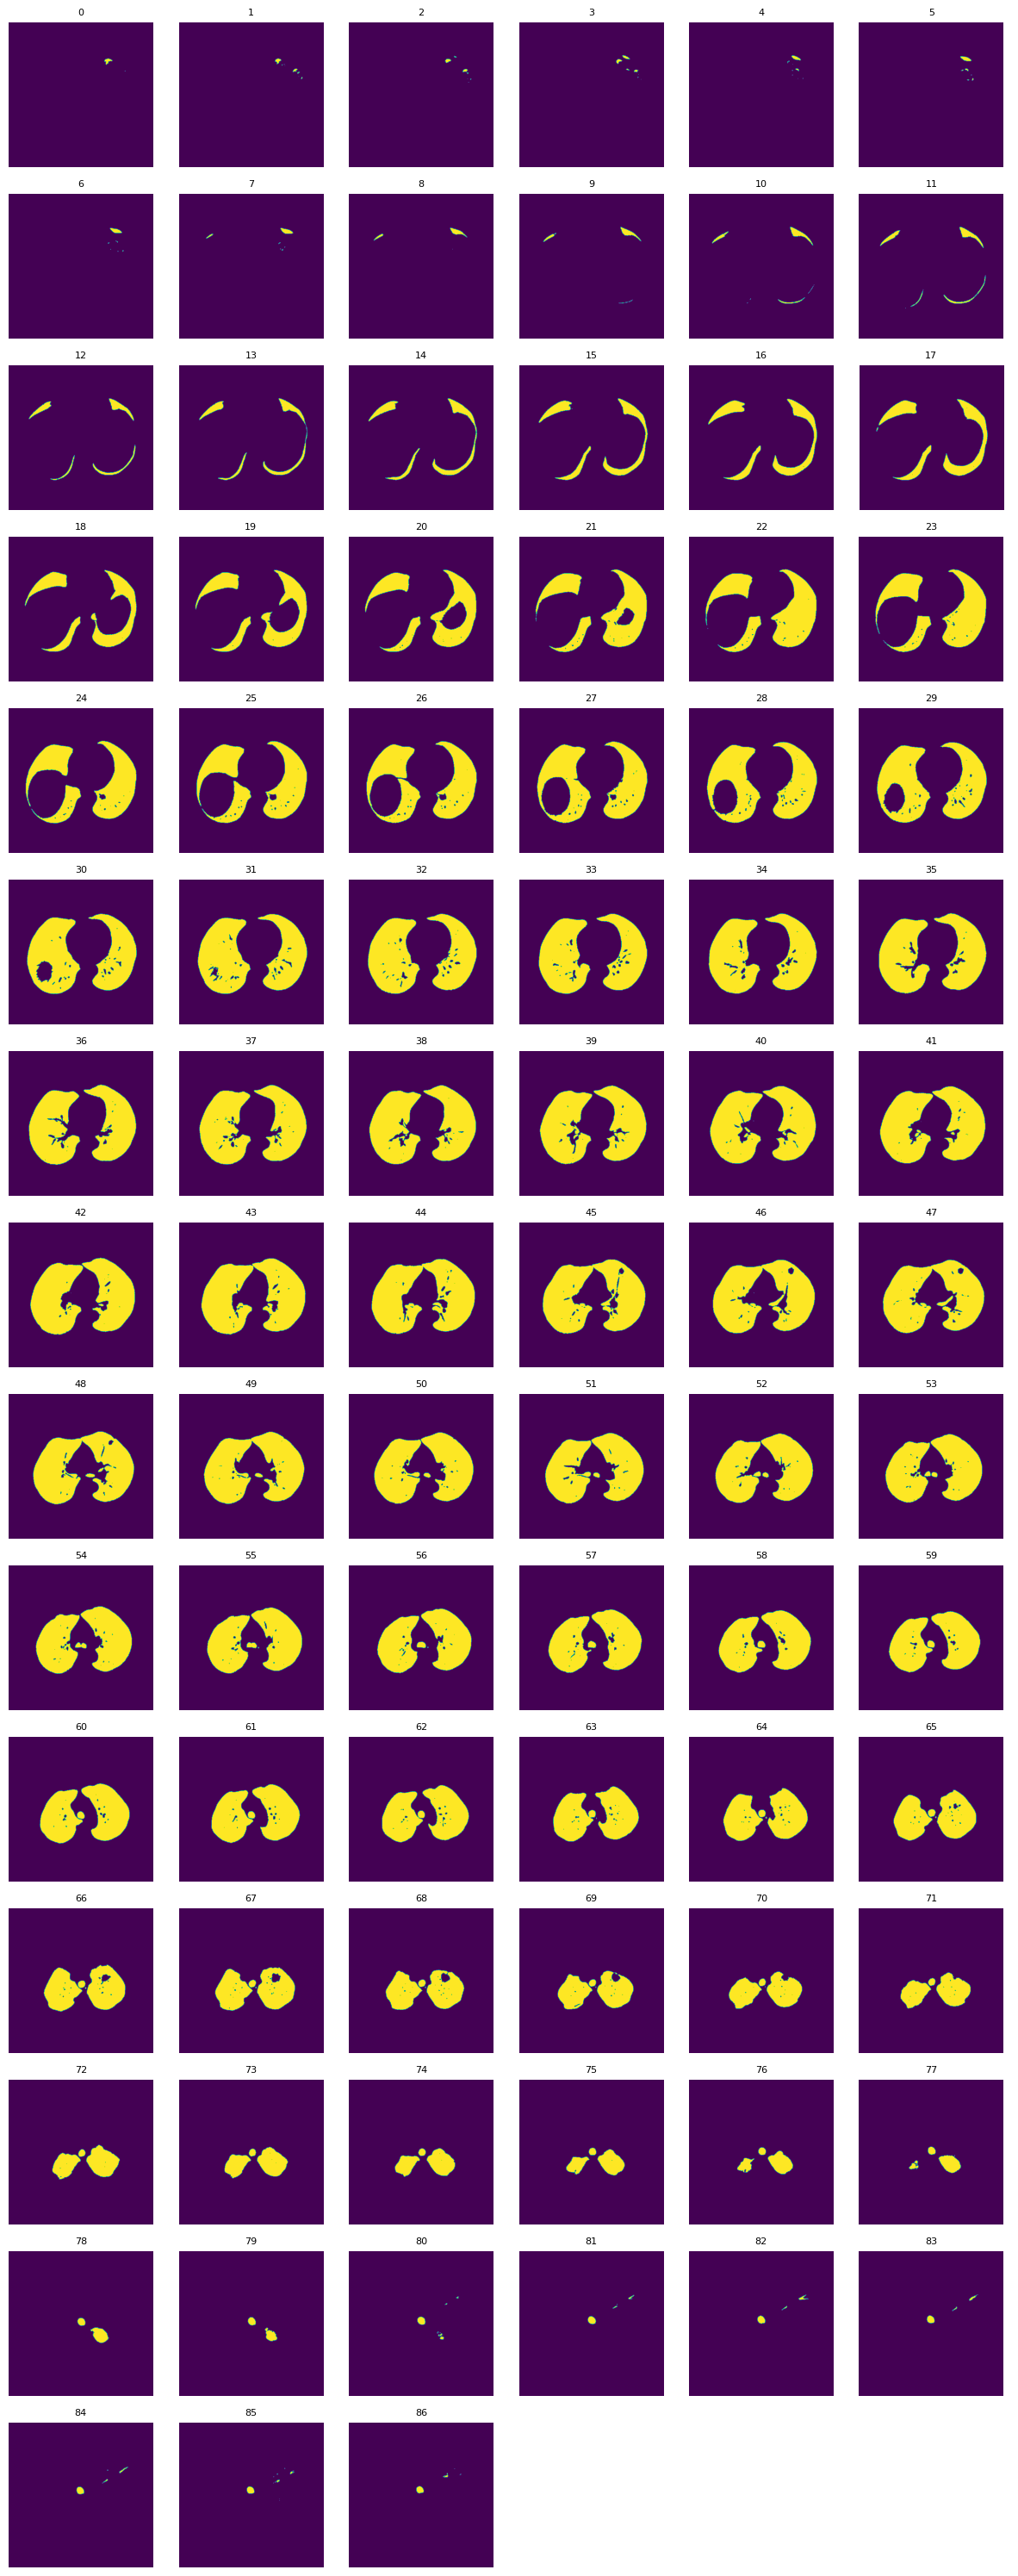

In [7]:
# Remove The Outer Border Using clear_border
# (n,m) => n: height, m: width
# (n,m)->(n,m)
# 2D input (n,m), 2D output -> (n,m) 
masks = np.vectorize(clear_border, signature='(n,m)->(n,m)')(masks)

# Visualization
show_slices_grid(masks)

# Identify Regions

label():
- https://scikit-image.org/docs/stable/api/skimage.measure.html#skimage.measure.label

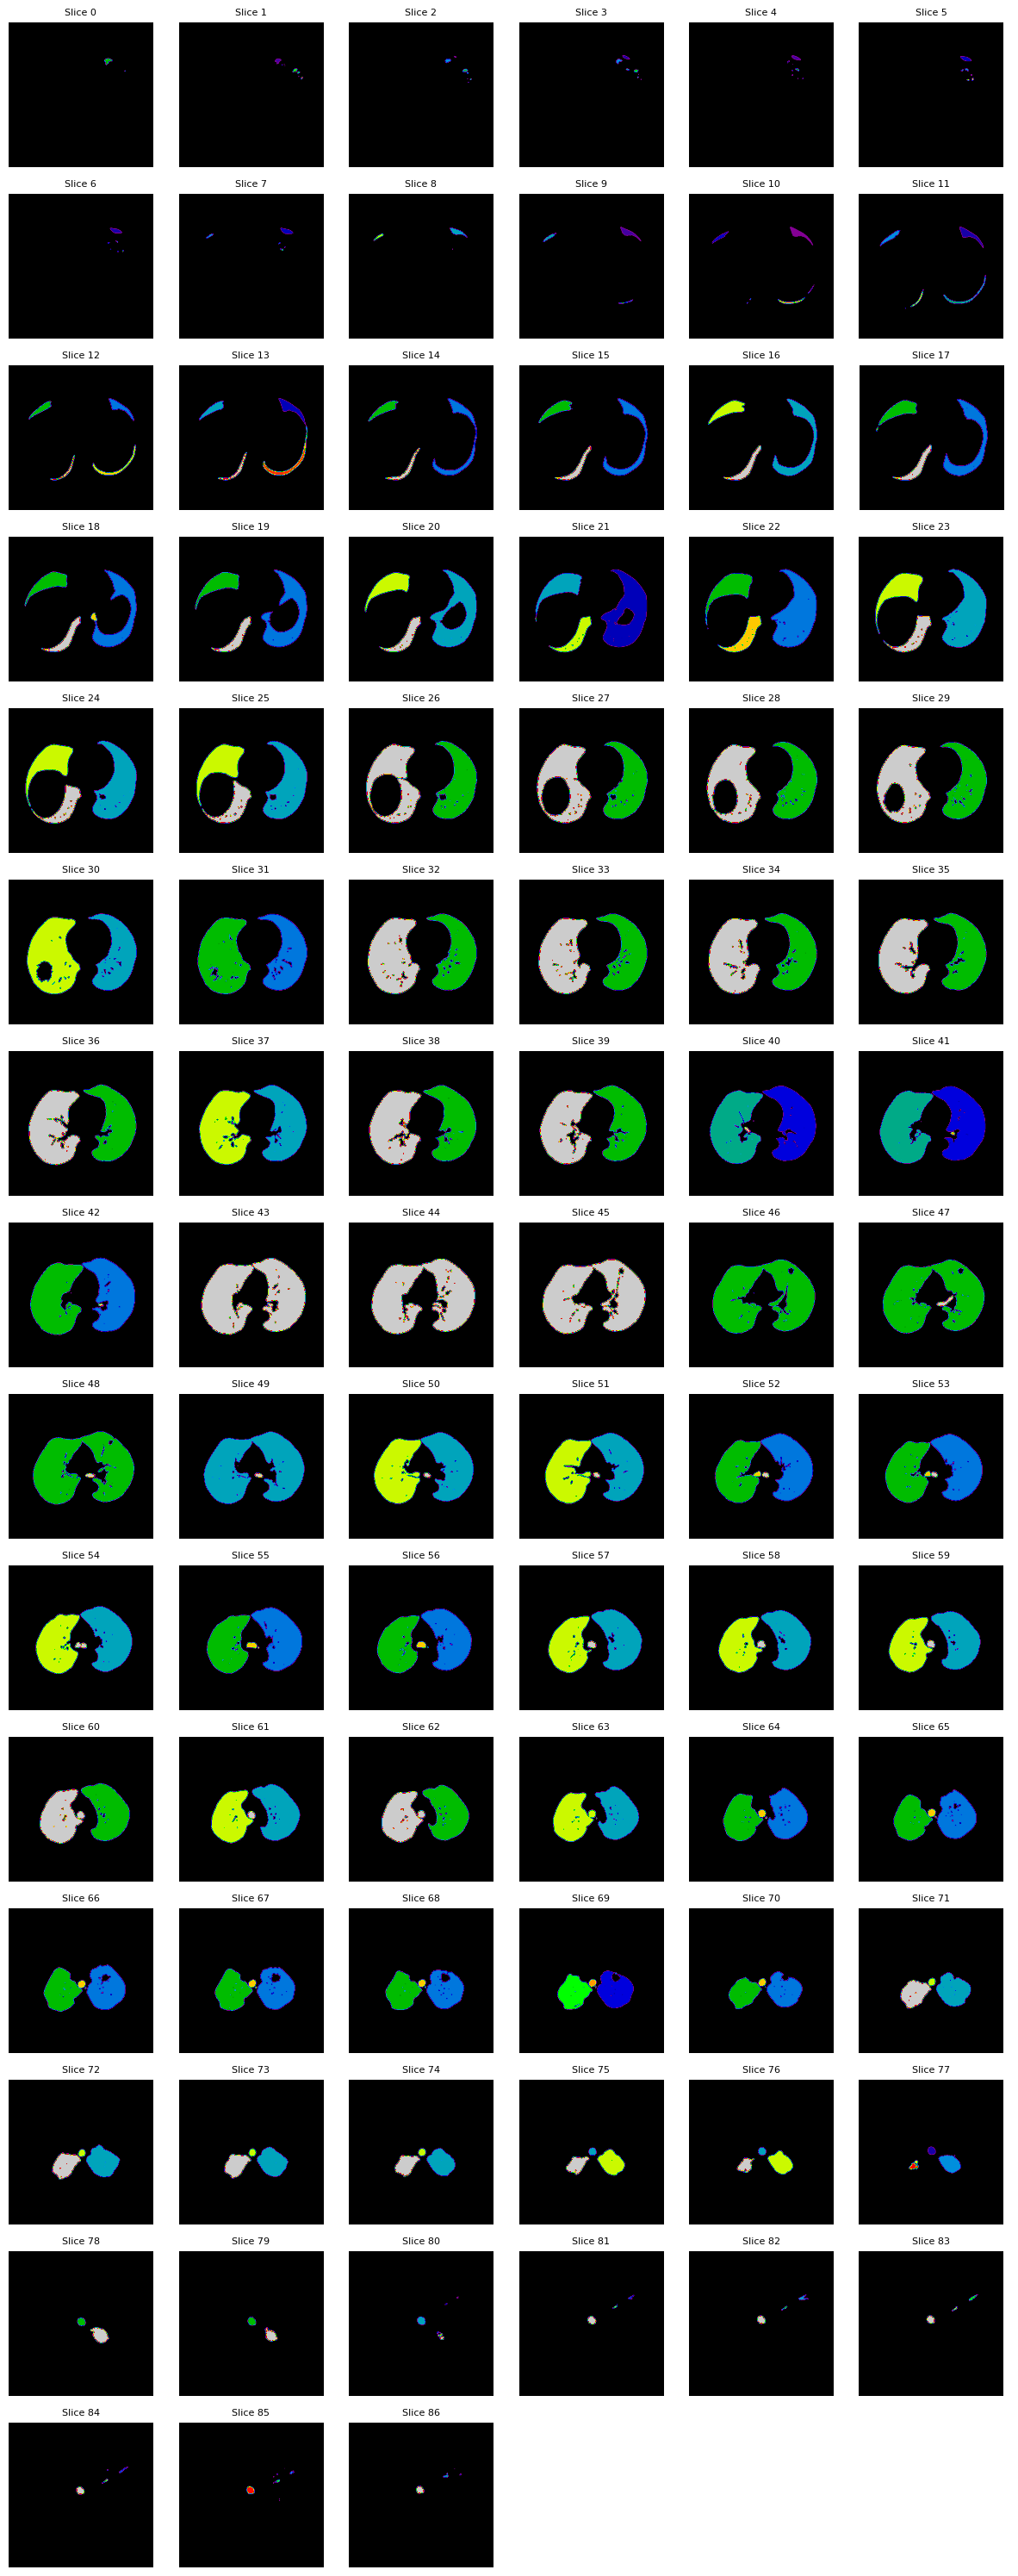

In [8]:
# labeling each regions
labels = label(masks)
show_labeled_slices_grid(masks)

regionprops():
- https://scikit-image.org/docs/stable/api/skimage.measure.html#skimage.measure.regionprops

sroted():
- https://docs.python.org/3/howto/sorting.html
- https://docs.python.org/3/library/functions.html#sorted

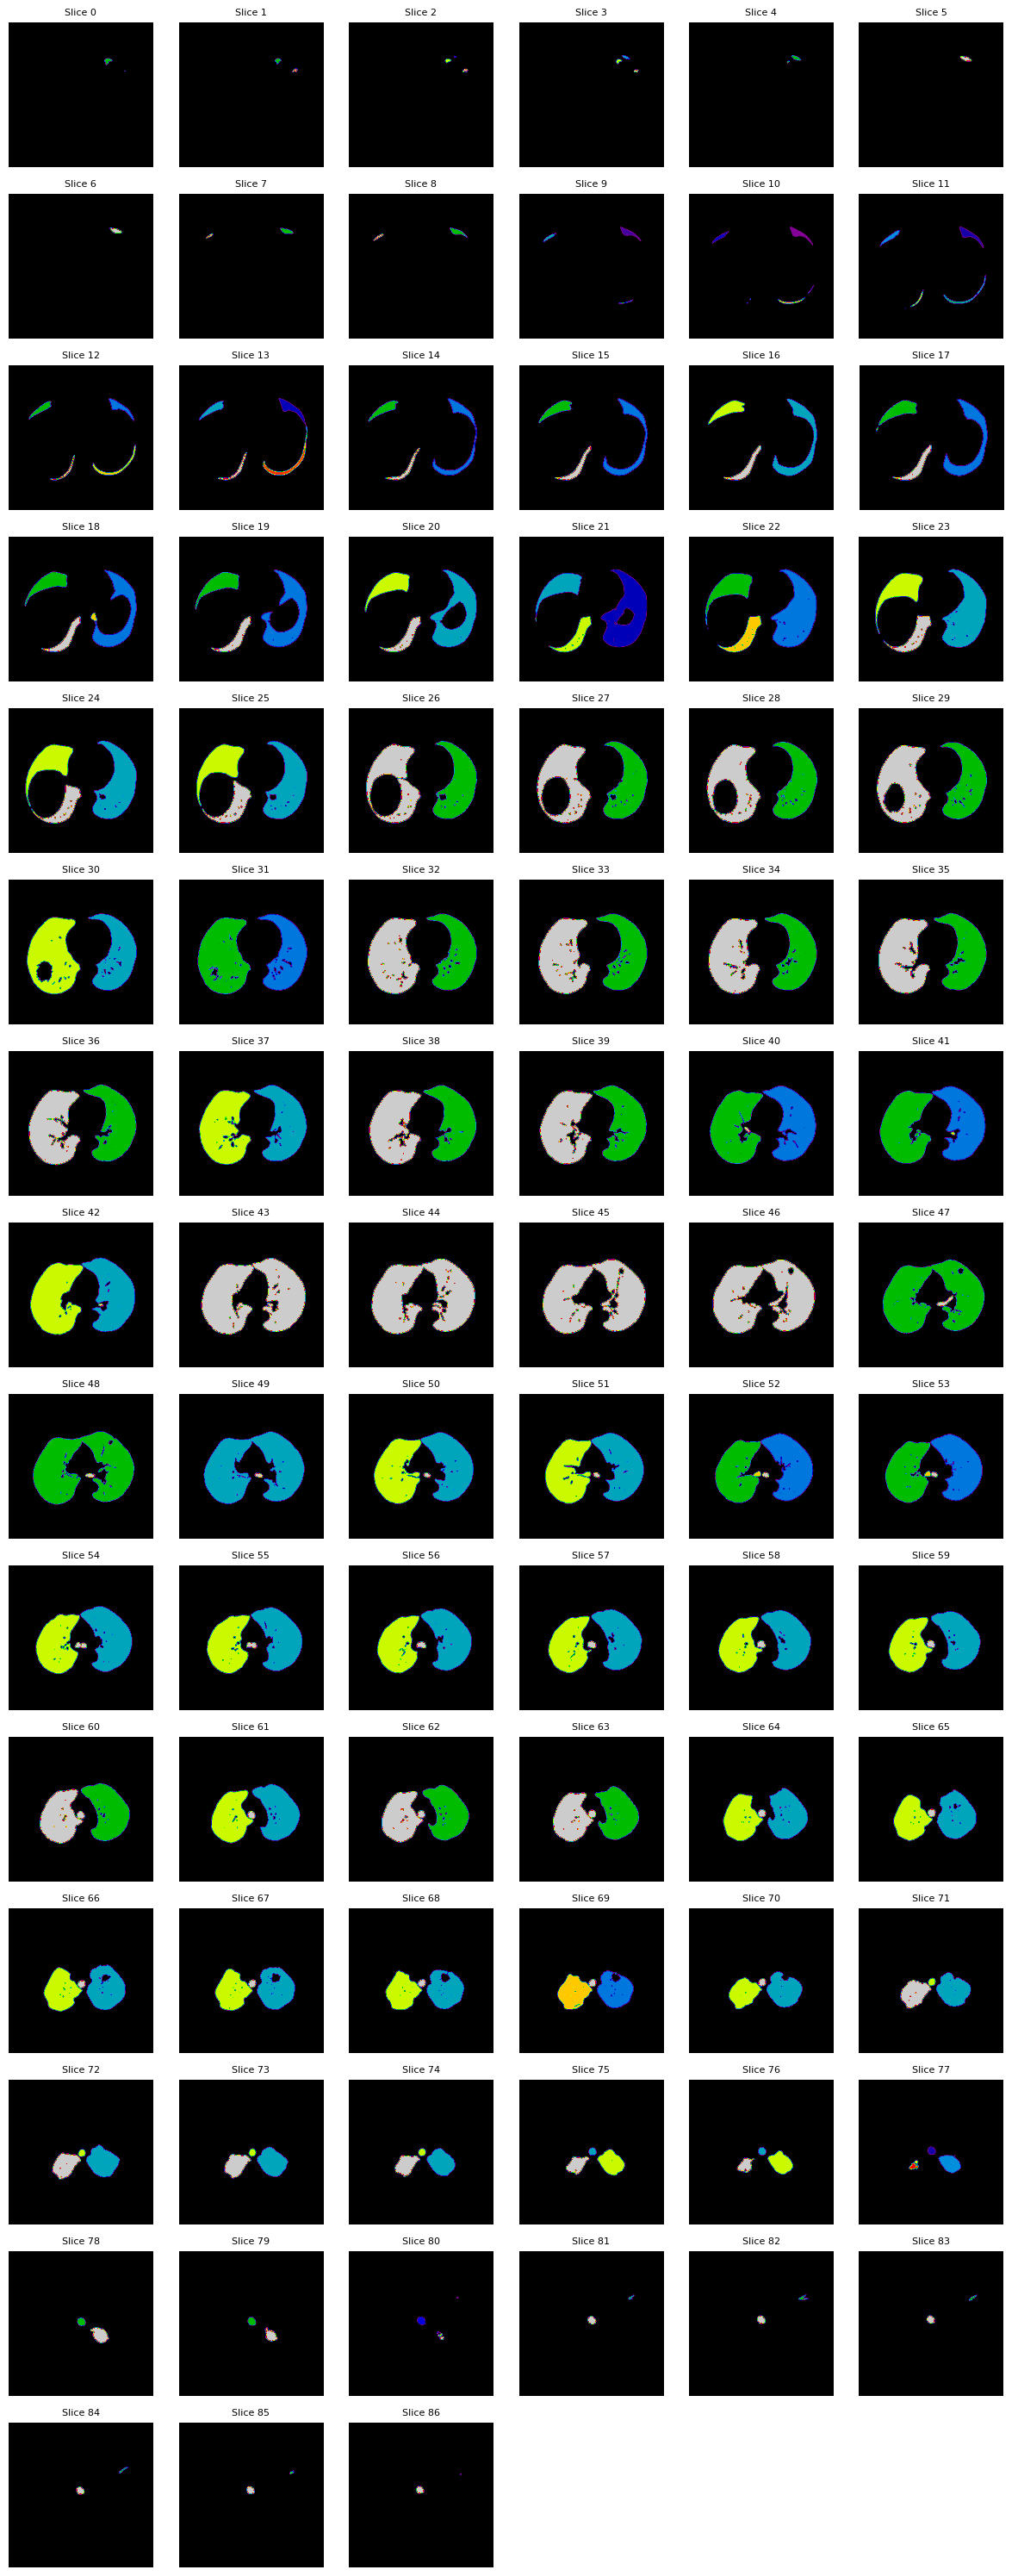

In [9]:
# Measure properties of labeled image regions
regions = regionprops(labels)

# Sort region area desending
regions_sorted = sorted(
    regions,
    key=lambda r: r.area,
    reverse=True
)

# Get The 4 Largest Area
top_4_regions = regions_sorted[:4]


top4_mask = np.zeros_like(labels, dtype=np.uint8)
for idx, region in enumerate(top_4_regions, start=1):
    top4_mask[labels == region.label] = idx

show_labeled_slices_grid(top4_mask)

# Opening Operation

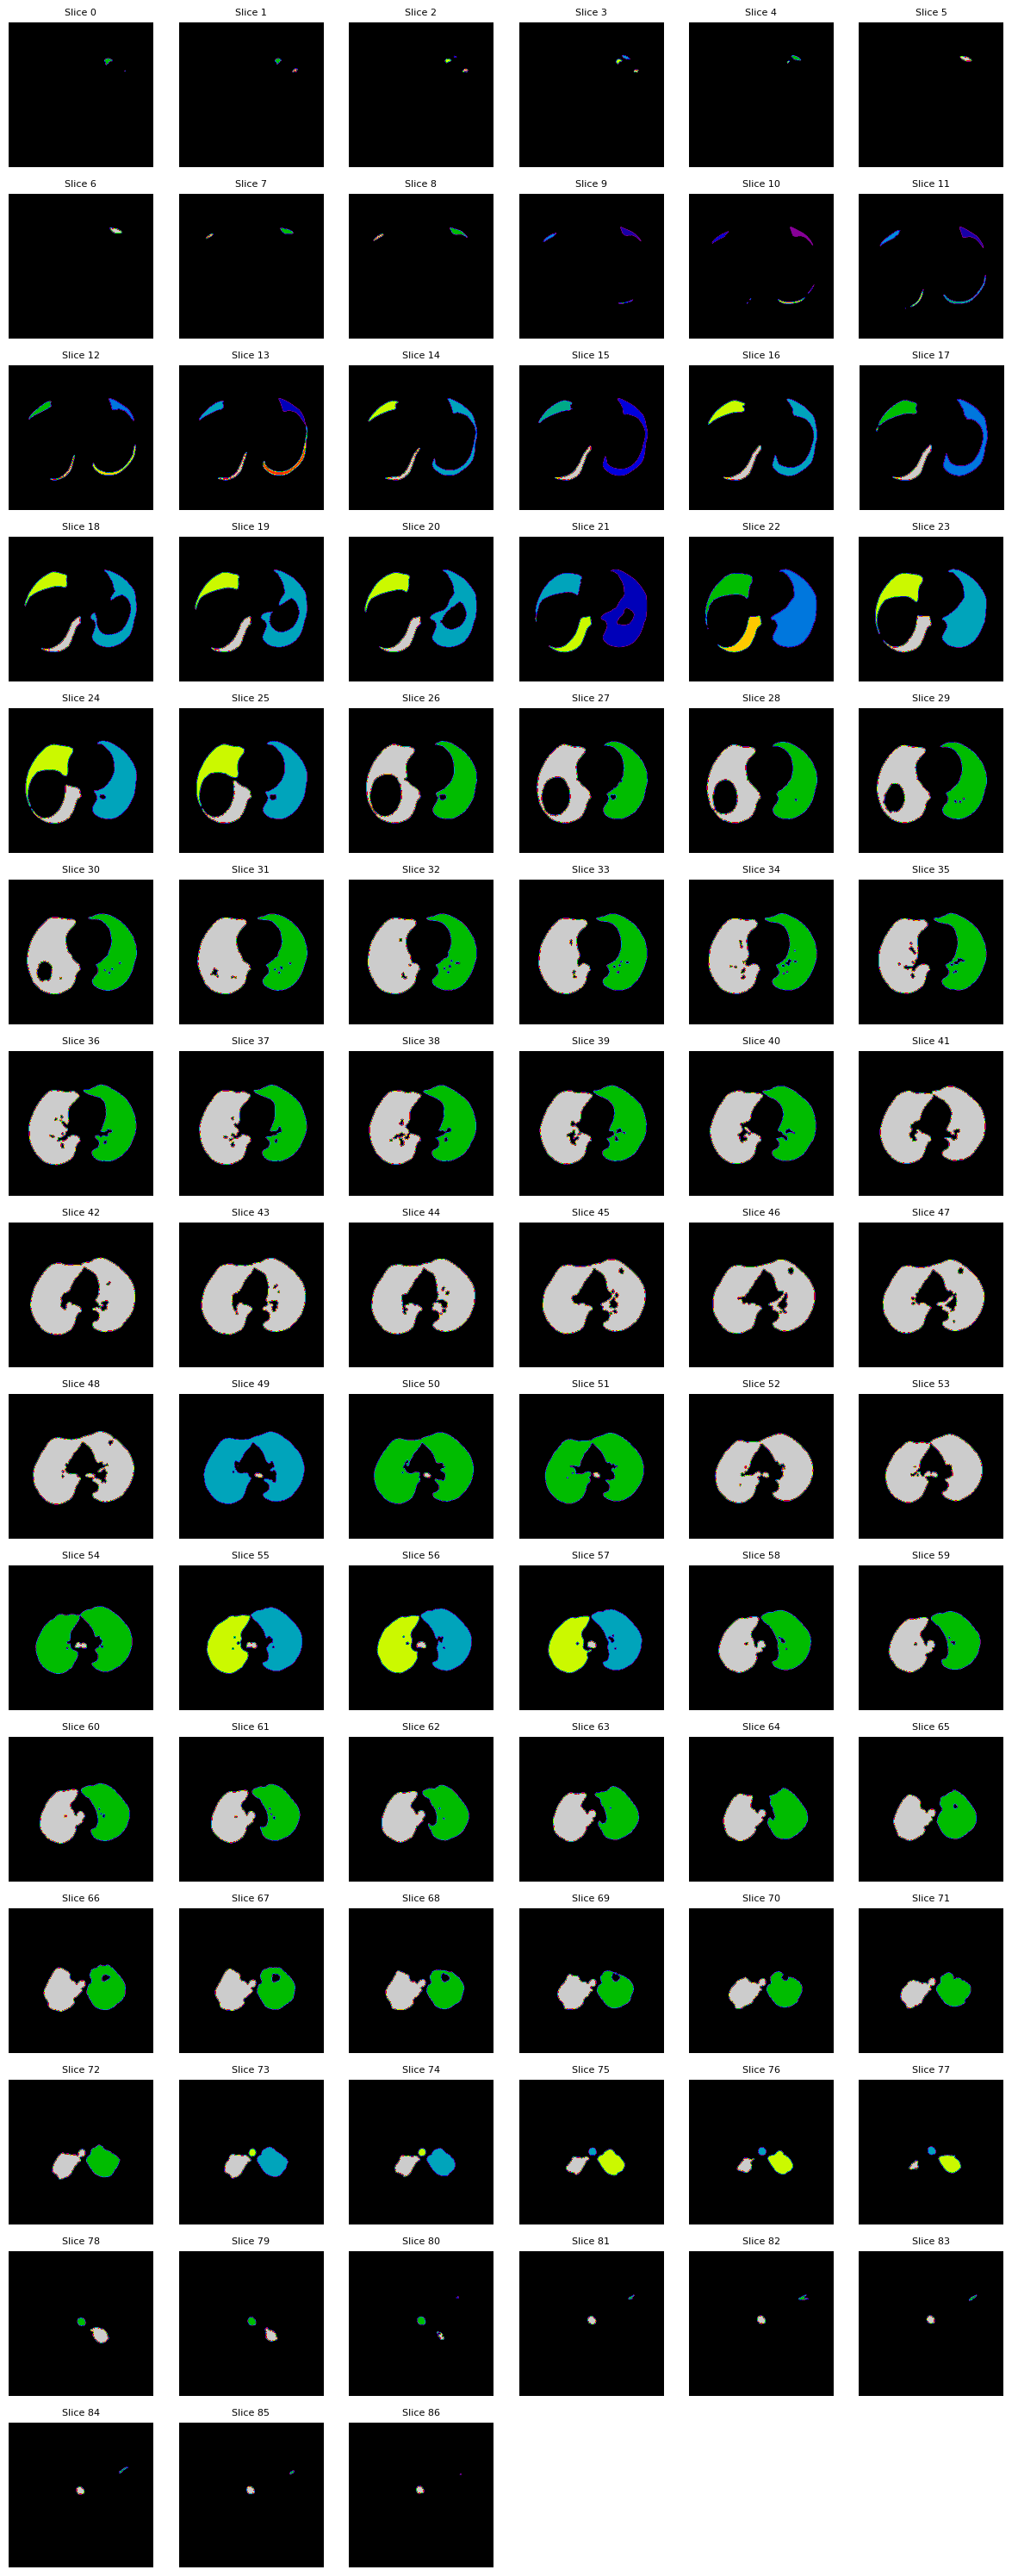

In [10]:
opened_top4_mask = np.zeros_like(top4_mask)

# Ambil label unik selain background
region_ids = np.unique(top4_mask)
region_ids = region_ids[region_ids != 0]

for region_id in region_ids:

    # Ambil region tertentu
    region_mask = (top4_mask == region_id)

    # Opening per-slice
    opened_slices = []

    for slice_ in region_mask:

        opened_slice = binary_closing(
            slice_,
            footprint=disk(3)
        )

        opened_slices.append(opened_slice)

    opened_slices = np.array(opened_slices)

    # Kembalikan label region
    opened_top4_mask[opened_slices] = region_id


# Visualisasi
show_labeled_slices_grid(
    opened_top4_mask,
    cmap='nipy_spectral'
)

- Ambil 4 Area Terbesar
- Opening
- F